# Annotations

1. Concatenating two CSV files containing the hair annotations for groups B and N (preliminary assignment)

In [1]:
import pandas as pd 
df_b = pd.read_csv("../data/group_B.csv", delimiter=";")
df_n = pd.read_csv("../data/group_N.csv", delimiter=";")

merged_df= pd.concat([df_b, df_n], ignore_index=True)
merged_df.to_csv("../data/hair_annotations_b_and_n.csv", index = False)

2. Using Fleiss Kappa to analyse the agreement between annotators

In [2]:
from statsmodels.stats.inter_rater import fleiss_kappa
import pandas as pd

df = pd.read_csv("../data/hair_annotations_b_and_n.csv")
ratings = df[["annotator_1", "annotator_2", "annotator_3", "annotator_4", "annotator_5"]]

def counting(row):
    counts = [0,0,0,0]
    for v in row:
        if v == 0:
            counts[0] += 1
        elif v == 1:
            counts[1] += 1
        elif v== 2:
            counts[2] += 1
        elif v == 3:
            counts[3] += 1
    return counts

#new dataframe with rating frequencies
df_rating = ratings.apply(counting, axis = 1, result_type = "expand")

#use fleiss kappa function
data_matrix = df_rating.values
kappa = fleiss_kappa(data_matrix, method="fleiss")
print(f"Fleiss´ Kappa = {kappa: .3f}")

Fleiss´ Kappa =  0.760


- < 0.40: Poor to fair (low consistency)
- 0.41 - 0.60: Moderate (acceptable consistency)
- 0.61 - 0.80: Substantial (strong consistency)
- 0.81 - 1.00: Almost perfect (high reliability) 

3. Creating figures to compare annotators

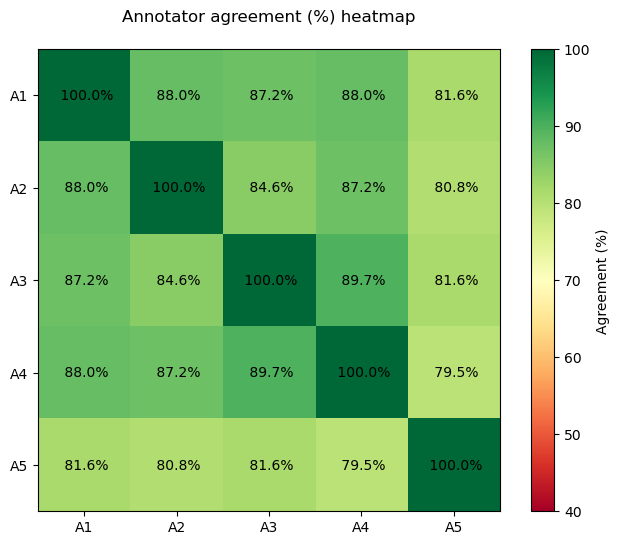

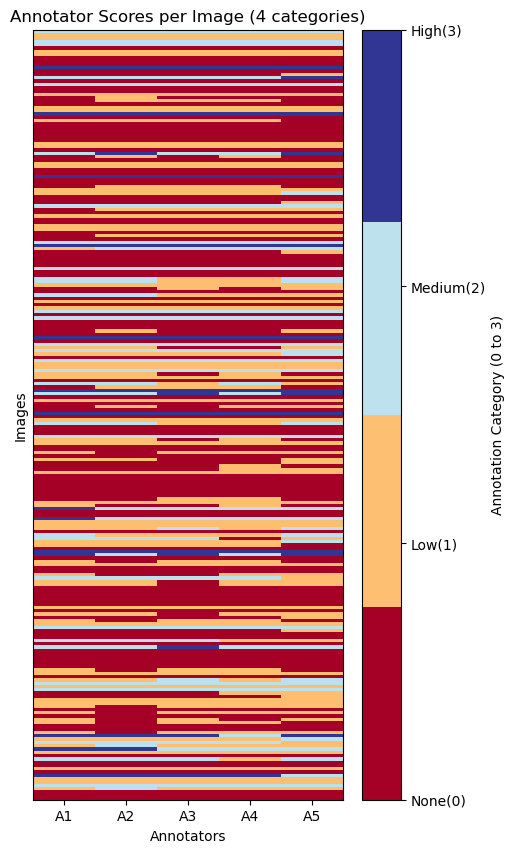

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/hair_annotations_b_and_n.csv")
df = df.filter(like = "annotator_").astype(int)
n_annotators = df.shape[1]

def get_agreement_matrix(data):
    n = data.shape[1]
    matrix = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            #Calculating the percentage of times that the ratings of annotators i and j match
            percentage = (data.iloc[:, i] == data.iloc[:, j]).mean() * 100
            matrix[i, j] = percentage
    return matrix

agreement_matrix = get_agreement_matrix(df)

#Figure 1 - Heatmap
plt.figure(figsize=(8,6))
cmap_agreement = plt.get_cmap("RdYlGn")
im1 = plt.imshow(agreement_matrix, cmap=cmap_agreement, vmin=40, vmax=100)

for i in range(n_annotators):
    for j in range(n_annotators):
        plt.text(j, i, f"{agreement_matrix[i,j]: .1f}%", ha="center", va="center", color="black", fontsize=10)

plt.title("Annotator agreement (%) heatmap", pad=20)
plt.xticks(range(n_annotators), [f"A{i+1}" for i in range(n_annotators)])
plt.yticks(range(n_annotators), [f"A{i+1}" for i in range(n_annotators)])
cbar1 = plt.colorbar(im1)
cbar1.set_label("Agreement (%)")
plt.savefig("../results/figures/annotator_agreement_heatmap.png", dpi= 300, bbox_inches="tight")
plt.show()

#Figure 2 - Annotator scores
plt.figure(figsize=(5,10))
cmap_4 = plt.get_cmap("RdYlBu", 4)

im2 = plt.imshow(df.values, cmap=cmap_4, aspect="auto")

plt.title("Annotator Scores per Image (4 categories)")
plt.xlabel("Annotators")
plt.ylabel("Images")
plt.xticks(range(n_annotators), [f"A{i+1}" for i in range(n_annotators)])
plt.yticks([], [])

cbar = plt.colorbar(im2, ticks = [0, 1, 2, 3])
cbar.set_label("Annotation Category (0 to 3)")
cbar.ax.set_yticklabels(["None(0)", "Low(1)", "Medium(2)", "High(3)"])
plt.savefig("../results/figures/annotation_scores_4cat.png", dpi=300, bbox_inches = "tight")
plt.show()


4. Dividing the agreements between annotators into three categories (low, medium, high) in order to analyse the reason

In [4]:
import pandas as pd
df = pd.read_csv("../data/hair_annotations_b_and_n.csv")
df = df.filter(like = "annotator_").astype(int)

def calculate_consensus(row):
    mode_val = row.mode()[0]
    return (row == mode_val).sum()

df["consensus_count"] = df.apply(calculate_consensus, axis = 1)

conditions = [(df["consensus_count"] >= 4), (df["consensus_count"] == 3), (df["consensus_count"] <= 2)]
labels = ["Robust agreement", "Moderate agreement", "Weak agreement"]

summary_data = {"Agreement level": labels, "Criteria": ["4-5 annotators", "3 annotators", "2 or less annotators"], "Image count": [len(df[cond])for cond in conditions], "Percentage(%)": [(len(df[cond]) / len(df) * 100) for cond in conditions]}

agreement_summary = pd.DataFrame(summary_data)
agreement_summary["Percentage(%)"] = agreement_summary["Percentage(%)"].round(2)

agreement_summary

,Agreement level,Criteria,Image count,Percentage(%)
0,Robust agreement,4-5 annotators,199,85.04
1,Moderate agreement,3 annotators,35,14.96
2,Weak agreement,2 or less annotators,0,0.00


5. Looking at pictures with moderate agreement to analyse the difference of the scores given by the annotators

In [5]:
import pandas as pd
df = pd.read_csv("../data/hair_annotations_b_and_n.csv")
df = df.filter(like = "annotator_").astype(int)

def analyze_row(row):
    mode_val = row.mode()[0]
    consensus = (row == mode_val).sum()
    spread = row.max() - row.min()
    return pd.Series([consensus, spread], index=["consensus", "spread"])

analysis = df.apply(analyze_row, axis = 1)

moderate_df = analysis[analysis["consensus"] == 3].copy()

diff_counts = moderate_df["spread"].value_counts().sort_index()

summary_diff = pd.DataFrame({"Disagreement range" : diff_counts.index,
    "Intensity":["Minor (Range 1)", "Significant (Range 2)", "Extreme (Range 3)"][:len(diff_counts)],
    "Count": diff_counts.values})
summary_diff

,Disagreement range,Intensity,Count
0,1,Minor (Range 1),34
1,2,Significant (Range 2),1


##### Printing an example of a picture before and after the hair_removal function

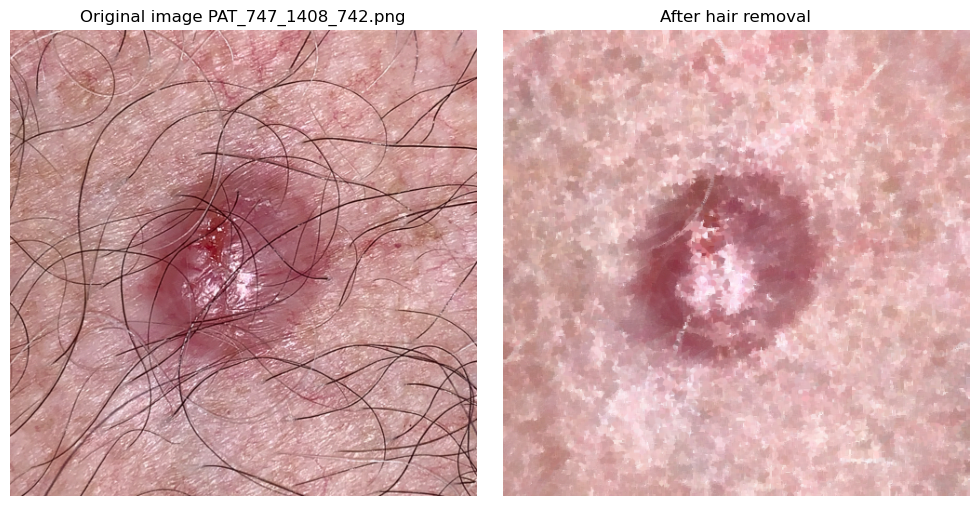

In [1]:
import cv2
import matplotlib.pyplot as plt
from hair_removal import remove_hair
img_path = "../data/imgs/PAT_747_1408_742.png"
img = cv2.imread(img_path)

img_no_hair, hair_mask = remove_hair(img)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_no_hair_rgb = cv2.cvtColor(img_no_hair, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title(f"Original image {img_path[13:]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_no_hair_rgb)
plt.title("After hair removal")
plt.axis("off")

plt.tight_layout()
plt.savefig("../results/figures/example_hair_removal.png", dpi = 300)
plt.show()